**Understanding the Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
from scipy import stats
import pickle

In [ ]:
df = pd.read_csv('dataset_churn.csv')

In [ ]:
df.head()

,Unnamed: 0,CustomerID,Age,Gender,Tenure,Service_Internet,Service_Phone,Service_TV,Contract,PaymentMethod,MonthlyCharges,TotalCharges,StreamingMovies,StreamingMusic,OnlineSecurity,TechSupport,Churn
0,0,08729464-bde6-43bc-8f63-a357096feab1,56.0,Male,13,DSL,Yes,No,One year,Mailed check,71.88,931.49,No,No,Yes,No,No
1,1,af95bc95-baf4-4318-a21d-70d2ea3148b7,69.0,Male,13,DSL,No,Yes,Two year,Mailed check,110.99,1448.46,Yes,Yes,No,No,No
2,2,1fe7eee6-2227-4400-9998-4d993f4a60fd,46.0,Male,60,Fiber optic,No,Yes,Month-to-month,Mailed check,116.74,6997.73,Yes,Yes,No,No,No
3,3,f736fe7b-1b44-4acd-84c2-21c4aef648be,32.0,Female,57,Fiber optic,Yes,Yes,Month-to-month,Bank transfer,78.16,4452.13,No,Yes,No,Yes,No
4,4,4b40d12d-7633-4309-96b8-aee675ea20ae,60.0,Male,52,Fiber optic,Yes,Yes,Two year,Electronic check,30.33,1569.73,Yes,No,Yes,Yes,No


In [ ]:
df.shape

(3749, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3749 entries, 0 to 3748
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        3749 non-null   int64  
 1   CustomerID        3749 non-null   object 
 2   Age               3562 non-null   float64
 3   Gender            3749 non-null   object 
 4   Tenure            3749 non-null   int64  
 5   Service_Internet  3028 non-null   object 
 6   Service_Phone     3749 non-null   object 
 7   Service_TV        3749 non-null   object 
 8   Contract          3749 non-null   object 
 9   PaymentMethod     3562 non-null   object 
 10  MonthlyCharges    3749 non-null   float64
 11  TotalCharges      3749 non-null   float64
 12  StreamingMovies   3749 non-null   object 
 13  StreamingMusic    3749 non-null   object 
 14  OnlineSecurity    3749 non-null   object 
 15  TechSupport       3749 non-null   object 
 16  Churn             3749 non-null   object 


In [ ]:
df.describe()

,Unnamed: 0,Age,Tenure,MonthlyCharges,TotalCharges
count,3749.000000,3562.000000,3749.000000,3749.000000,3749.000000
mean,1874.000000,43.655531,36.264070,75.844318,2718.968266
std,1082.387408,14.914474,20.505528,73.062971,3211.879149
min,0.000000,18.000000,1.000000,20.000000,13.190000
25%,937.000000,31.000000,19.000000,44.570000,1076.240000
50%,1874.000000,44.000000,36.000000,69.590000,2132.260000
75%,2811.000000,56.000000,54.000000,95.540000,3619.710000
max,3748.000000,69.000000,71.000000,1179.300000,79951.800000


In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

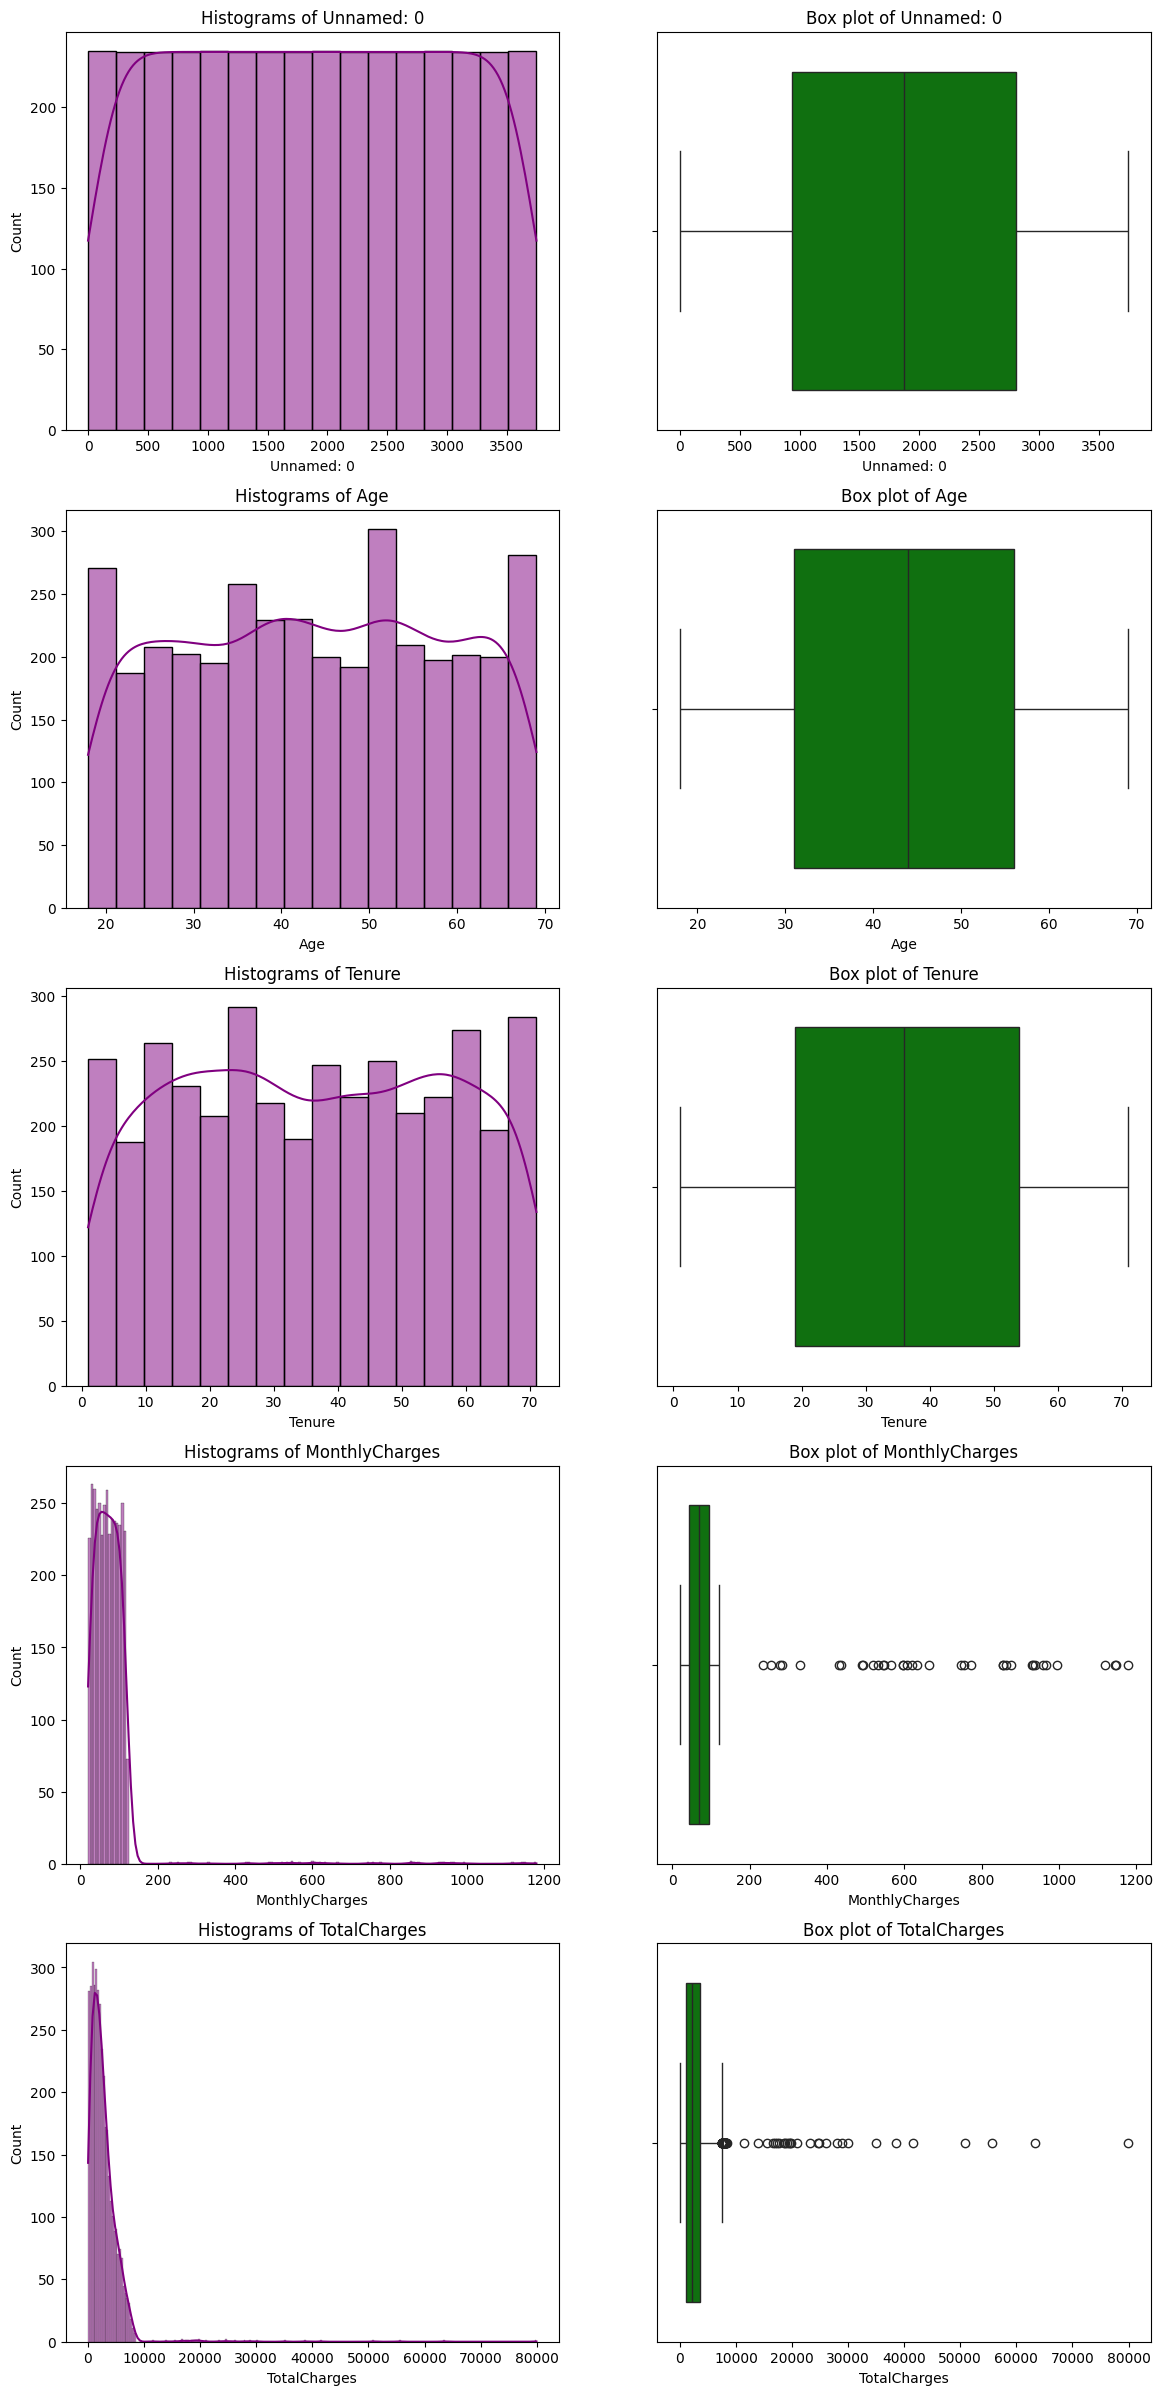

In [ ]:
fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(14, len(numerical_cols) * 6))

for i, col in enumerate(numerical_cols):
  sns.histplot(df[col].dropna(), kde=True, ax=axes[i, 0], color='purple')
  axes[i, 0].set_title(f'Histograms of {col}')

  sns.boxplot(x=df[col].dropna(), ax=axes[i, 1], color='green')
  axes[i, 1].set_title(f'Box plot of {col}')

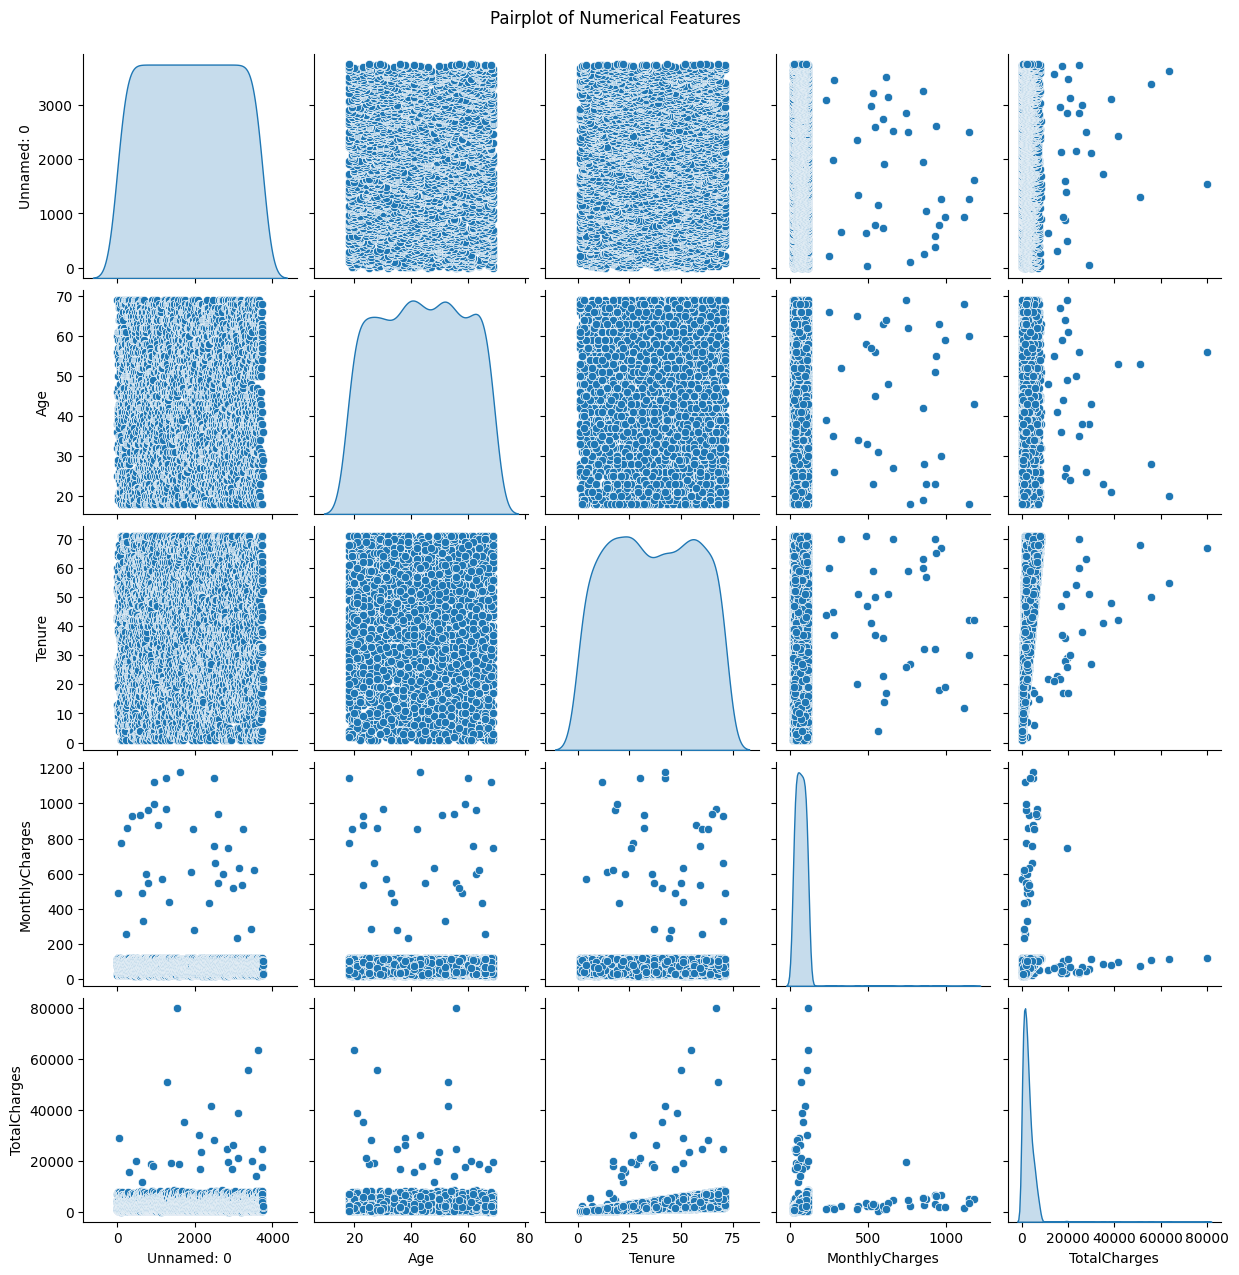

In [ ]:
sns.pairplot(df[numerical_cols], diag_kind='kde')
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

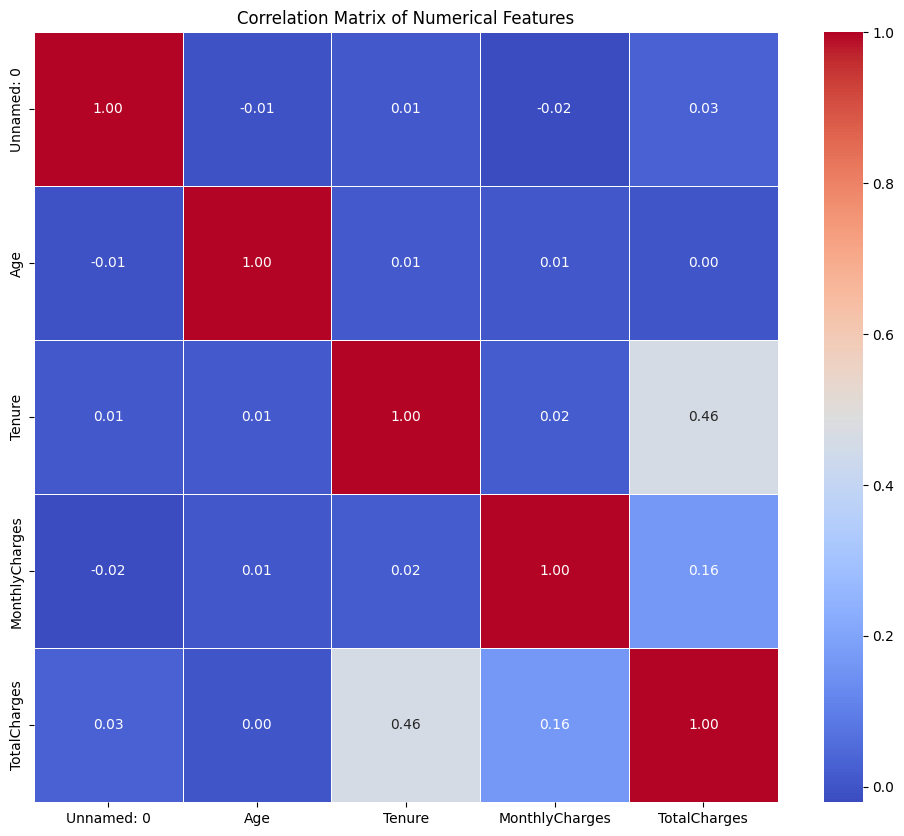

In [ ]:
correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

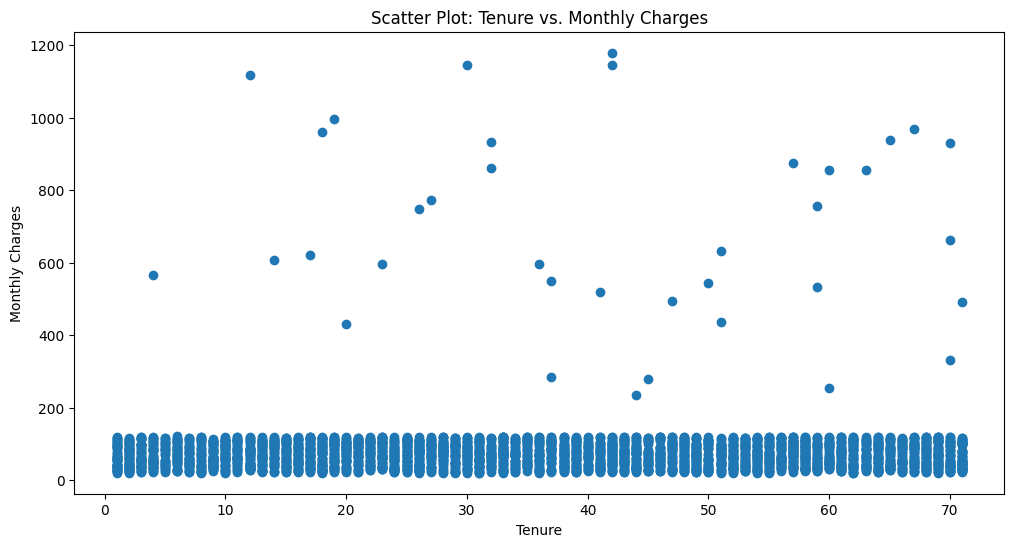

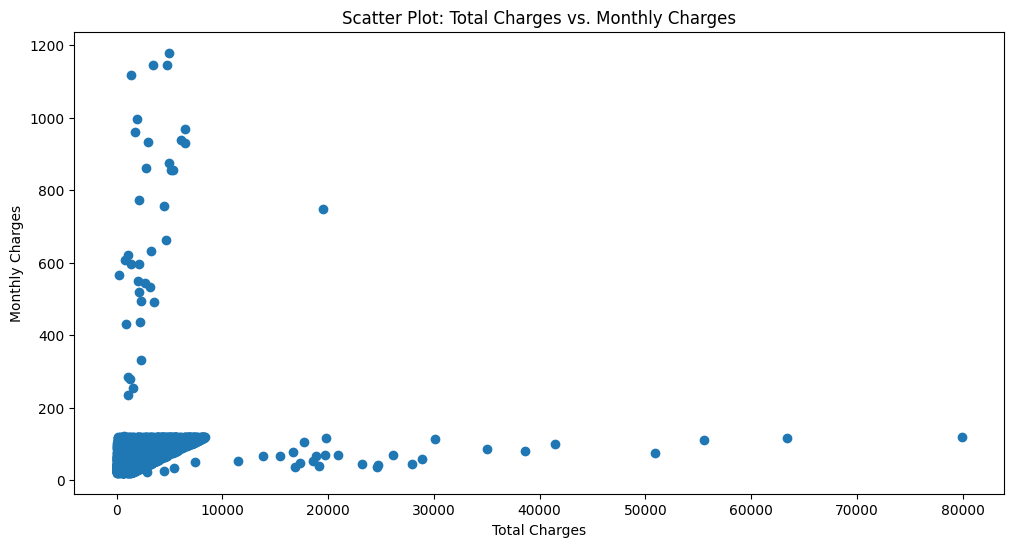

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(df['Tenure'], df['MonthlyCharges'])
plt.xlabel('Tenure')
plt.ylabel('Monthly Charges')
plt.title('Scatter Plot: Tenure vs. Monthly Charges')
plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(df['TotalCharges'], df['MonthlyCharges'])
plt.xlabel('Total Charges')
plt.ylabel('Monthly Charges')
plt.title('Scatter Plot: Total Charges vs. Monthly Charges')
plt.show()

**Data Preprocessing**

Data Cleaning and Preparation

In [ ]:
df = df.drop(['Unnamed: 0'], axis=1)
df = df.drop(['CustomerID'], axis=1)

In [ ]:
df.duplicated().value_counts()

,count
False,3749


In [ ]:
df.isnull().value_counts()

Age    Gender  Tenure  Service_Internet  Service_Phone  Service_TV  Contract  PaymentMethod  MonthlyCharges  TotalCharges  StreamingMovies  StreamingMusic  OnlineSecurity  TechSupport  Churn
False  False   False   False             False          False       False     False          False           False         False            False           False           False        False    2749
                       True              False          False       False     False          False           False         False            False           False           False        False     637
True   False   False   False             False          False       False     False          False           False         False            False           False           False        False     137
False  False   False   False             False          False       False     True           False           False         False            False           False           False        False     134
                       True              False          False       False     True           False           False         False            False           False           False        False      42
True   False   False   True              False          False       False     False          False           False         False            False           False           False        False      39
                       False             False          False       False     True           False           False         False            False           False           False        False       8
                       True              False          False       False     True           False           False         False            False           False           False        False       3
Name: count, dtype: int64

Handling missing values

In [ ]:
# Handling Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns
imputer_numerical = SimpleImputer(strategy='mean')
df[numerical_cols] = imputer_numerical.fit_transform(df[numerical_cols])

# Handling Categorical Columns
categorical_cols = df.select_dtypes(include='object').columns
imputer_categorical = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = imputer_categorical.fit_transform(df[categorical_cols])

In [ ]:
df.head()

,Age,Gender,Tenure,Service_Internet,Service_Phone,Service_TV,Contract,PaymentMethod,MonthlyCharges,TotalCharges,StreamingMovies,StreamingMusic,OnlineSecurity,TechSupport,Churn
0,56.0,Male,13.0,DSL,Yes,No,One year,Mailed check,71.88,931.49,No,No,Yes,No,No
1,69.0,Male,13.0,DSL,No,Yes,Two year,Mailed check,110.99,1448.46,Yes,Yes,No,No,No
2,46.0,Male,60.0,Fiber optic,No,Yes,Month-to-month,Mailed check,116.74,6997.73,Yes,Yes,No,No,No
3,32.0,Female,57.0,Fiber optic,Yes,Yes,Month-to-month,Bank transfer,78.16,4452.13,No,Yes,No,Yes,No
4,60.0,Male,52.0,Fiber optic,Yes,Yes,Two year,Electronic check,30.33,1569.73,Yes,No,Yes,Yes,No


Encoding the Categorical Attributes

In [ ]:
LE = LabelEncoder()
for col in categorical_cols:
    df[col] = LE.fit_transform(df[col])

Detecting and Treating the Outliers with Median

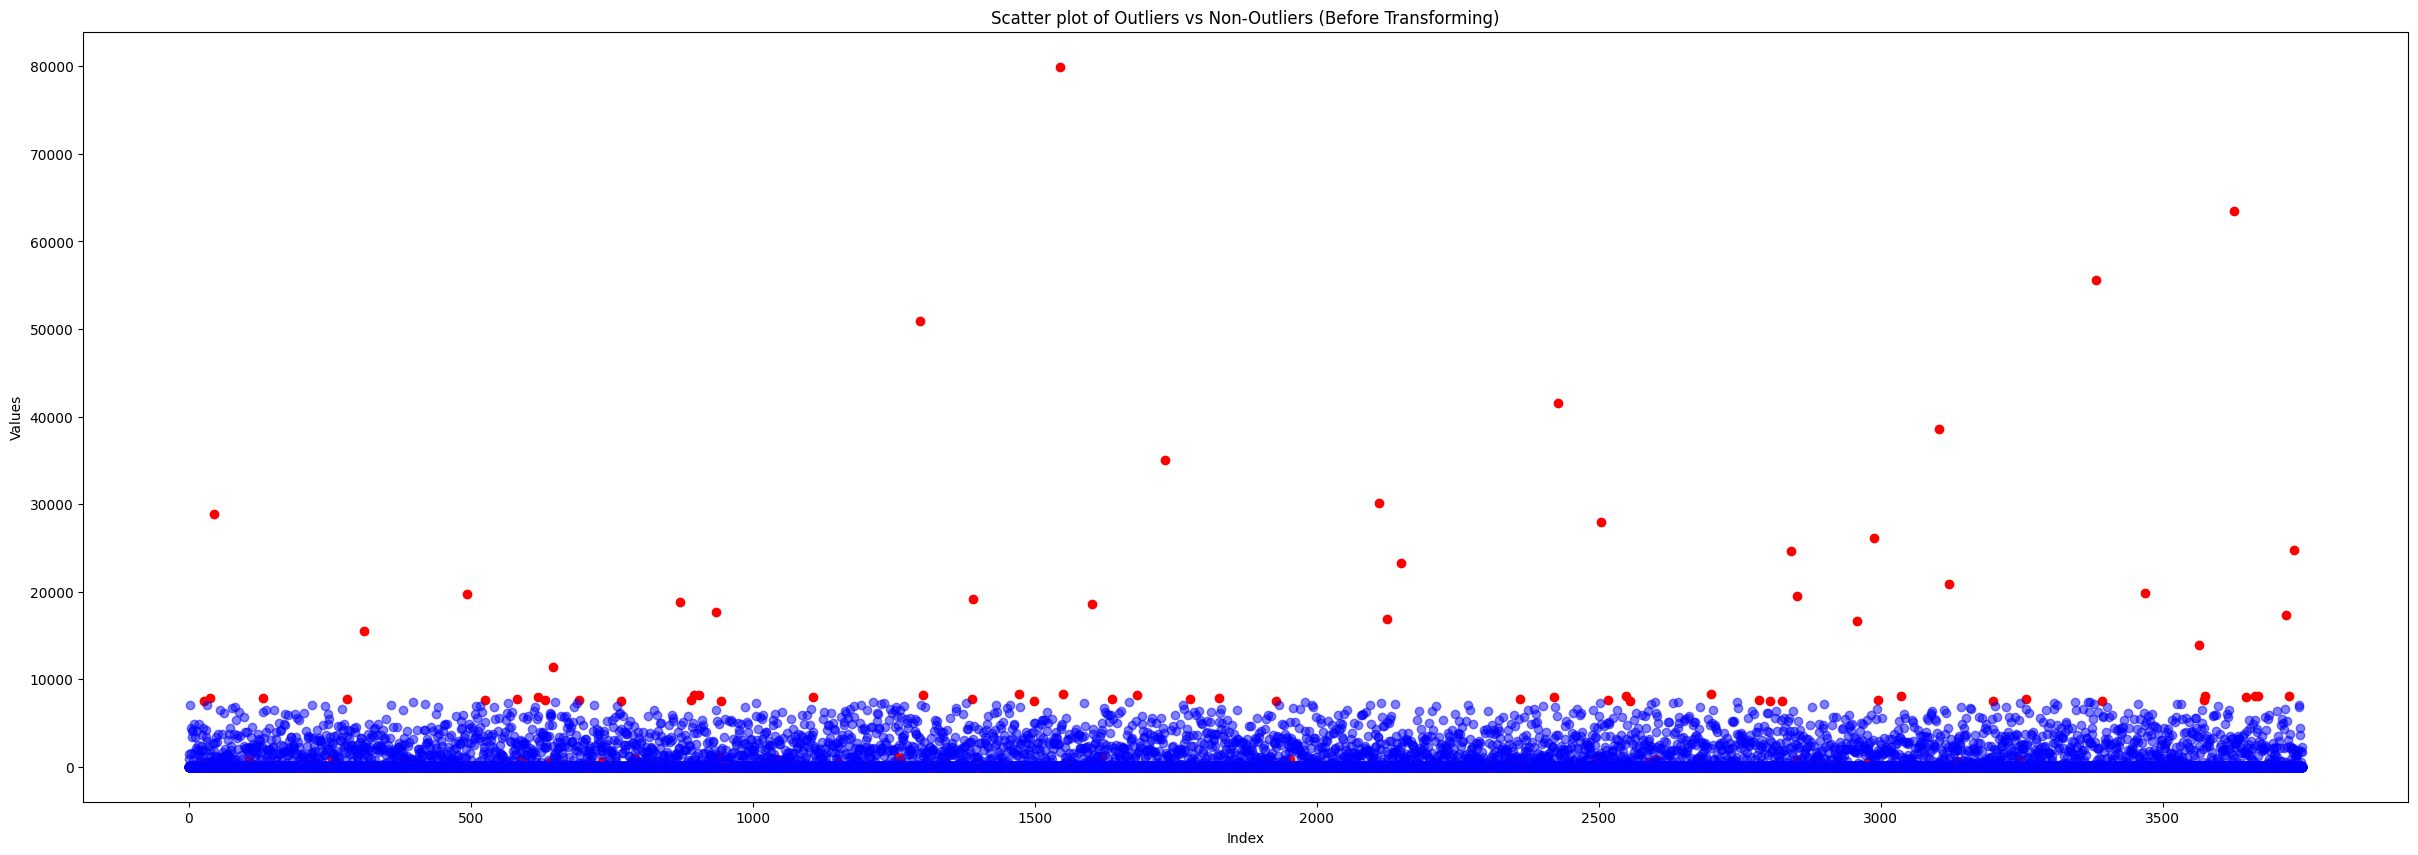

In [ ]:
def detect_outliers(features):
    q1 = features.quantile(0.25)
    q3 = features.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = (features < lower_bound) | (features > upper_bound)
    return outliers

plt.figure(figsize=(30, 10))
for column in df.select_dtypes(include='number').columns:
    outliers = detect_outliers(df[column])
    plt.scatter(df.index[outliers], df[column][outliers], color='red')
    plt.scatter(df.index[~outliers], df[column][~outliers], color='blue', alpha=0.5)
plt.title('Scatter plot of Outliers vs Non-Outliers (Before Transforming)')
plt.xlabel('Index')
plt.ylabel('Values')
plt.show()

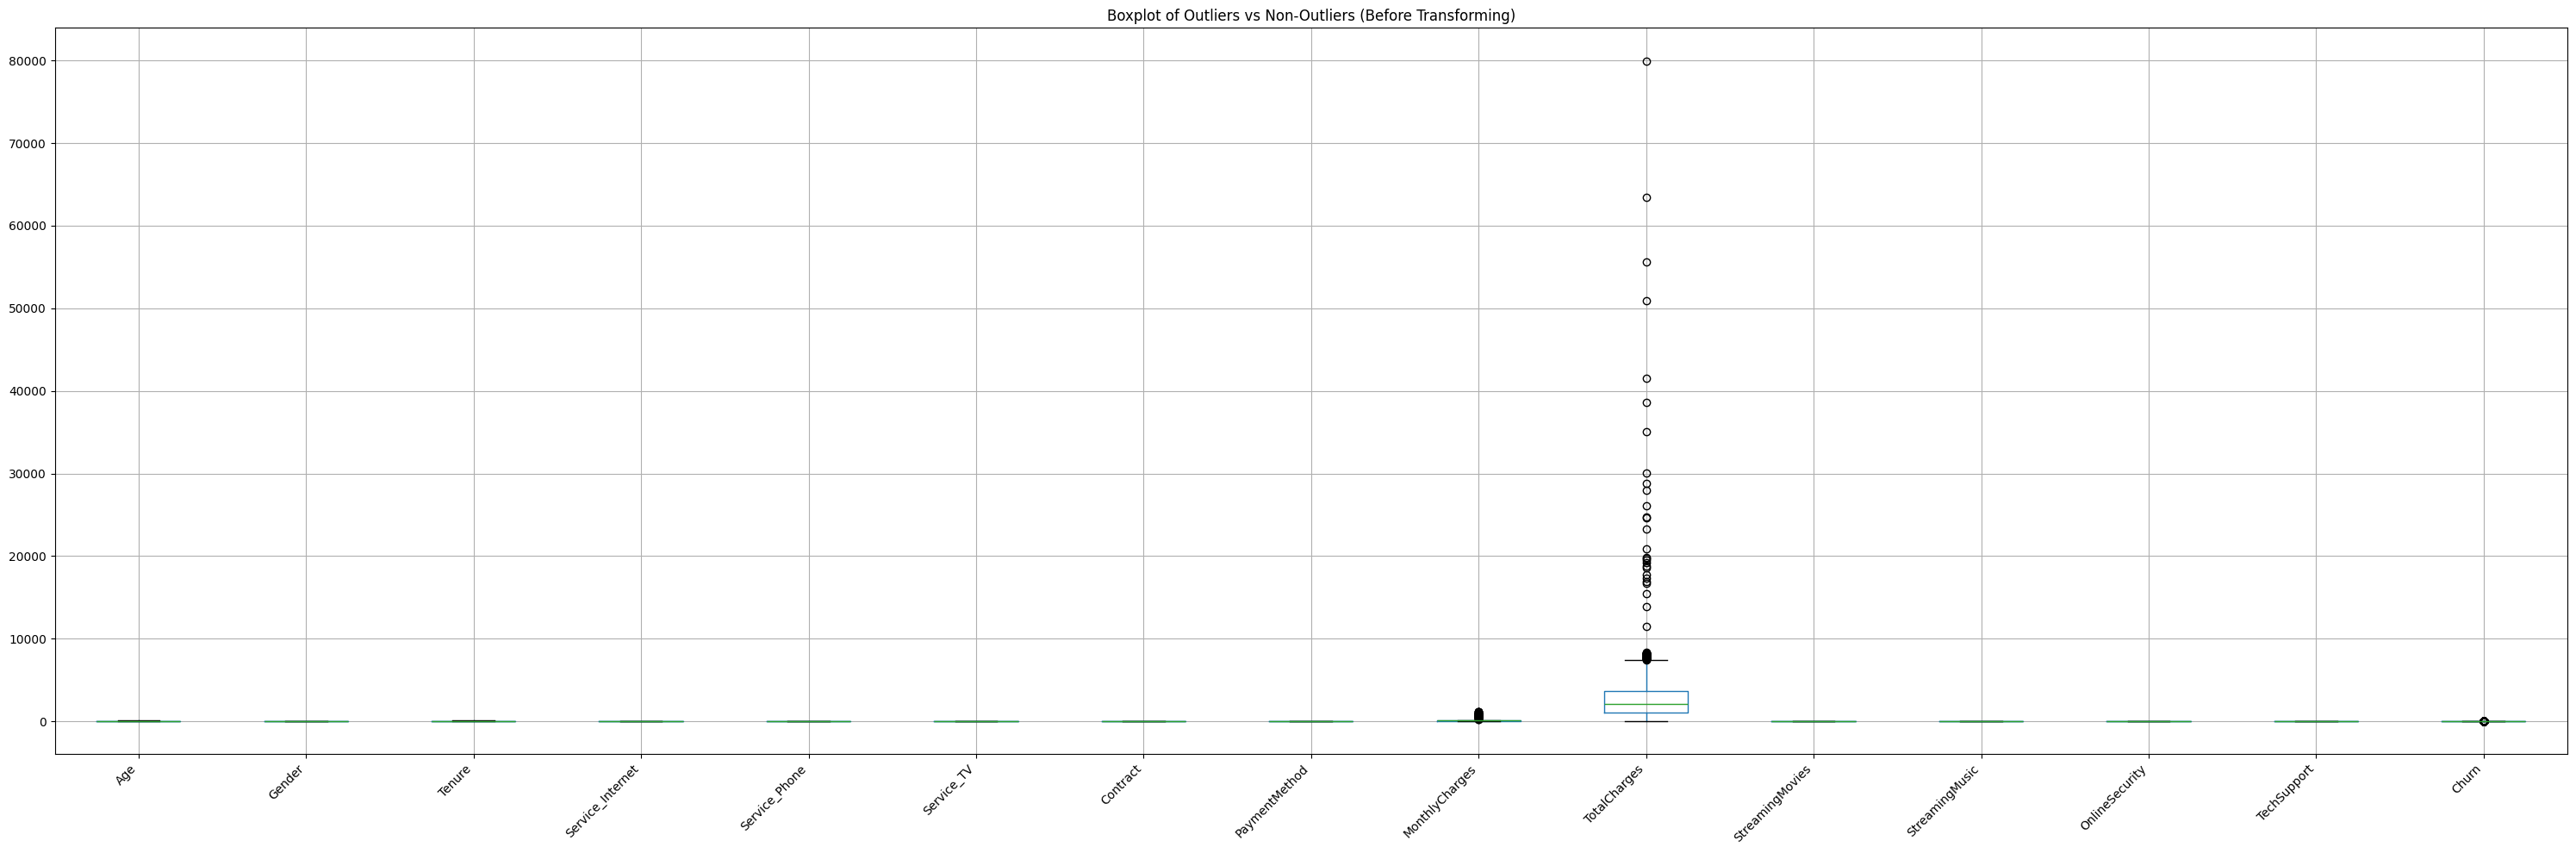

In [ ]:
plt.figure(figsize=(30, 10))
df.boxplot()
plt.title('Boxplot of Outliers vs Non-Outliers (Before Transforming)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
for column in df.select_dtypes(include='number').columns:
  if column != 'Churn':
    outliers = detect_outliers(df[column])
    df.loc[outliers, column] = df[column].median()

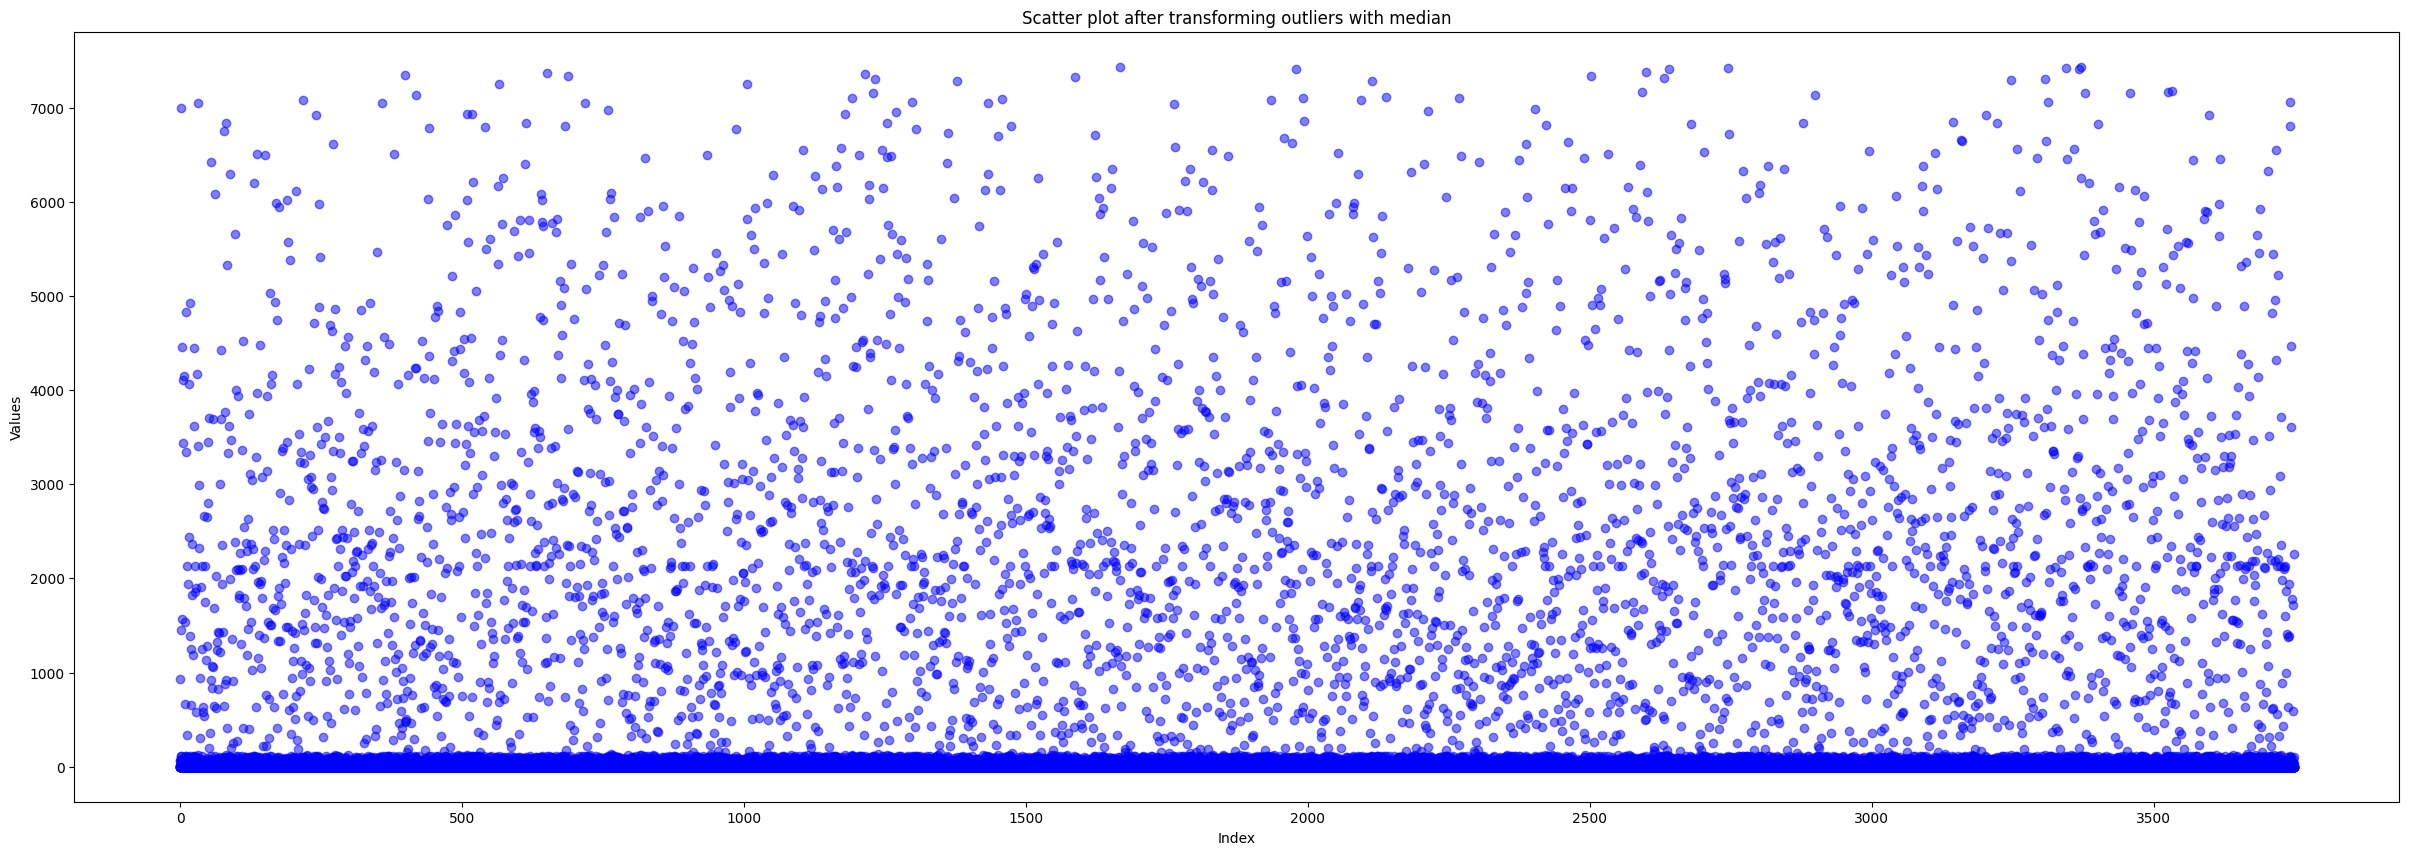

In [ ]:
# Visualize cleaned dataset
plt.figure(figsize=(30, 10))
for column in df.select_dtypes(include='number').columns:
    plt.scatter(df.index, df[column], color='blue', alpha=0.5)
plt.title('Scatter plot after transforming outliers with median')
plt.xlabel('Index')
plt.ylabel('Values')
plt.show()

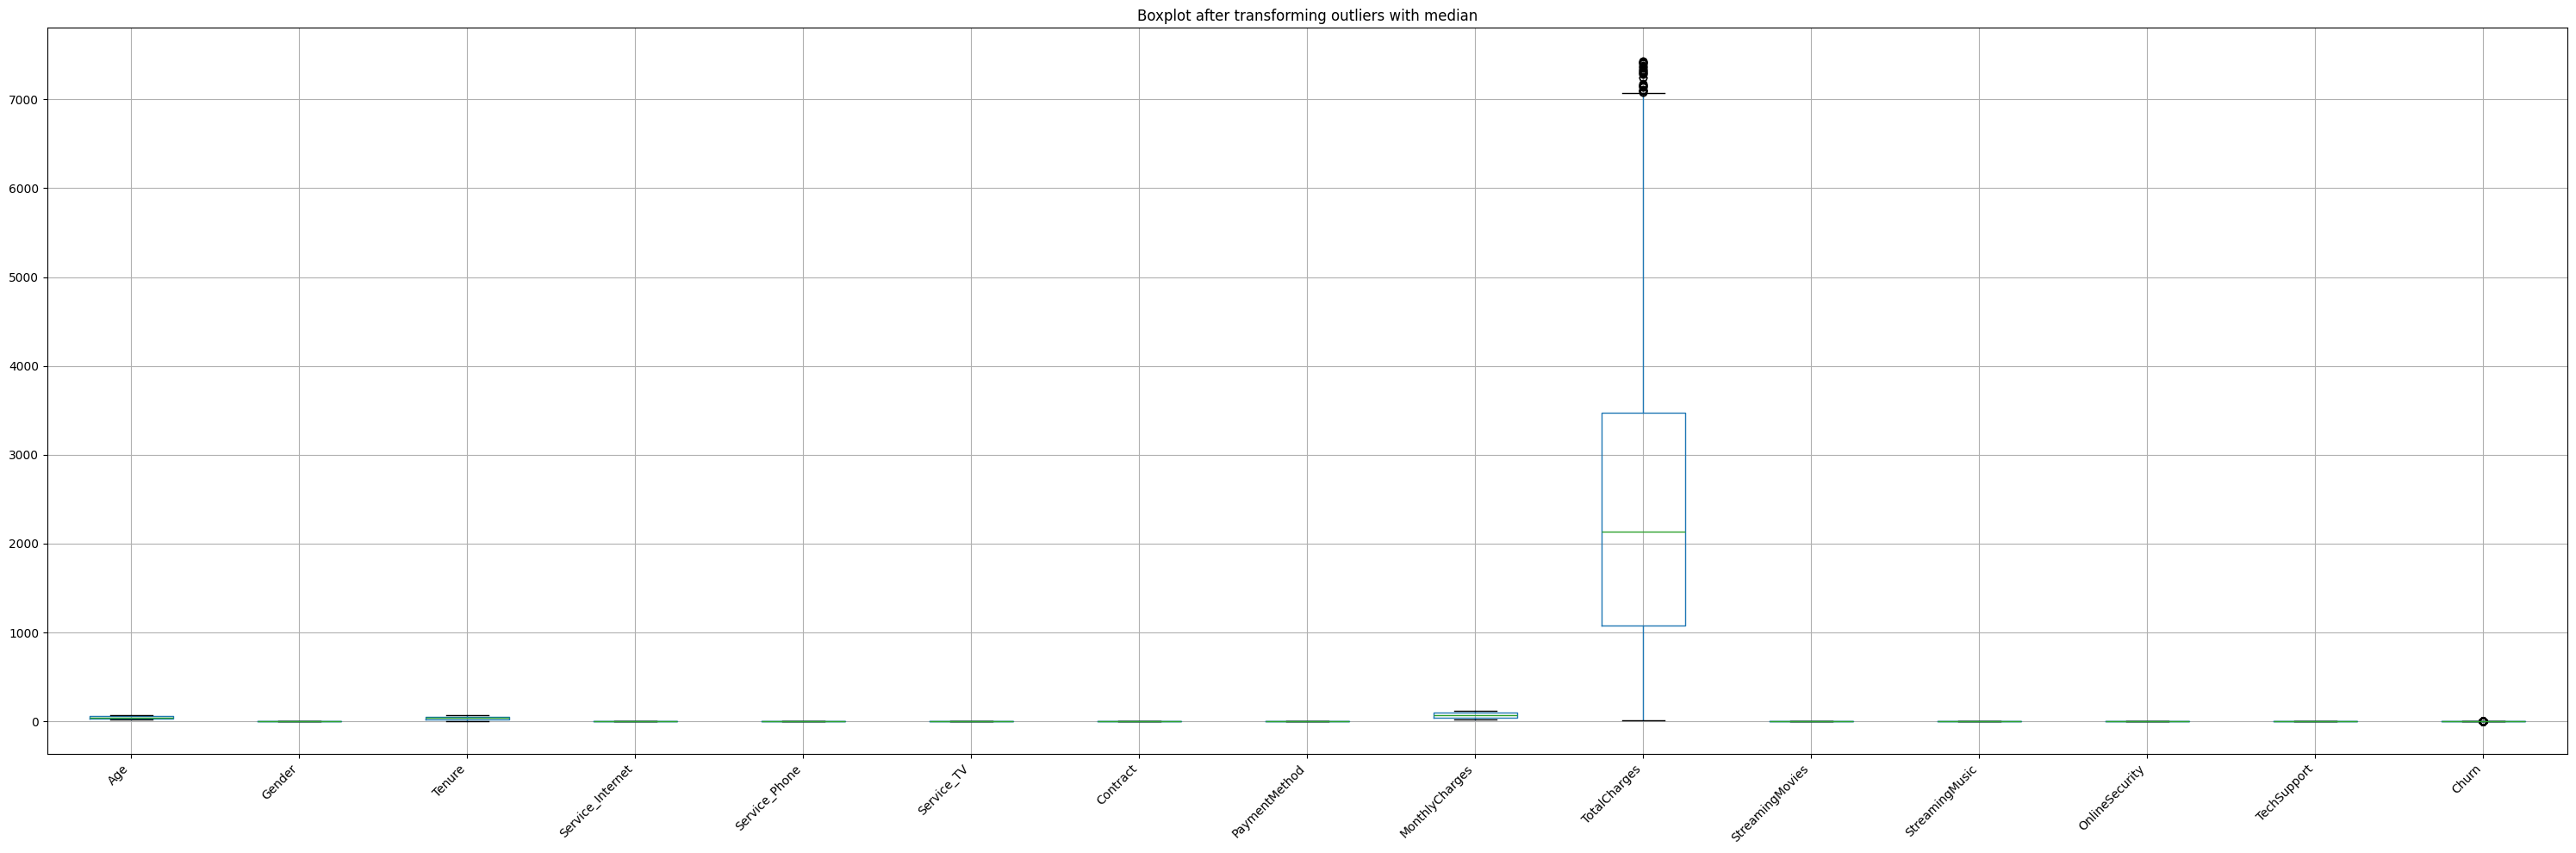

In [ ]:
plt.figure(figsize=(30, 10))
df.boxplot()
plt.title('Boxplot after transforming outliers with median')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df.to_csv('cleaned_dataset.csv', index=False)

**Exploratory Data Analysis**

In [ ]:
correlation = df.corr()['Churn'].sort_values(ascending=False)
print("Correlation with target variable:")
print(correlation)

Correlation with target variable:
Churn               1.000000
MonthlyCharges      0.239264
TechSupport         0.018568
Gender              0.006676
Age                -0.003401
StreamingMovies    -0.004435
Service_Internet   -0.004698
Service_TV         -0.005389
StreamingMusic     -0.009525
PaymentMethod      -0.009841
Contract           -0.011690
OnlineSecurity     -0.012379
Service_Phone      -0.019730
TotalCharges       -0.281448
Tenure             -0.392958
Name: Churn, dtype: float64


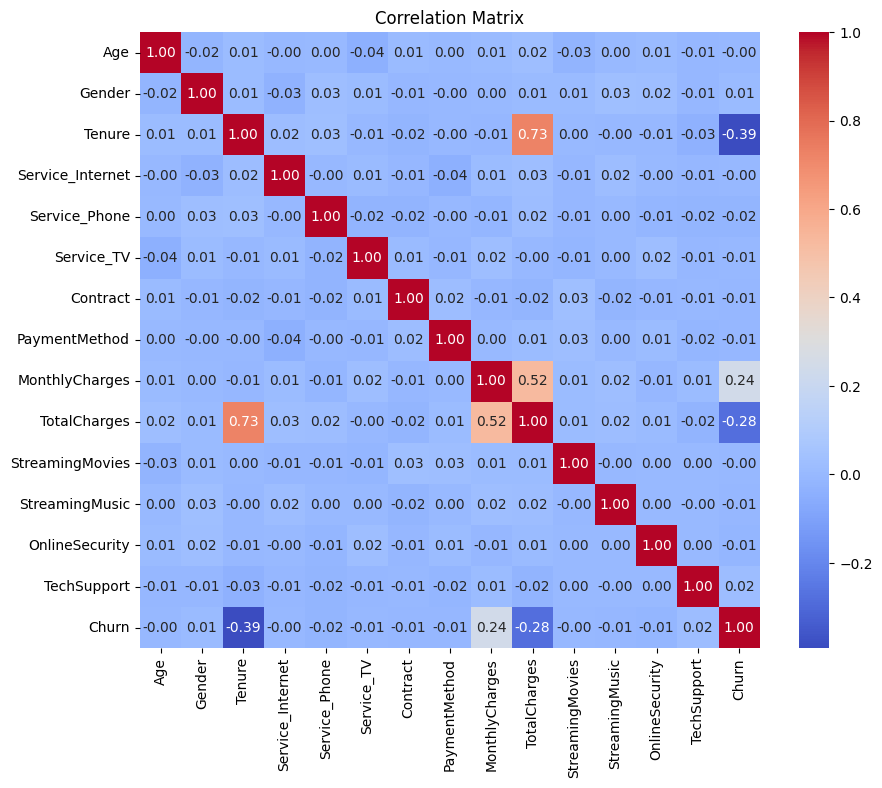

In [ ]:
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

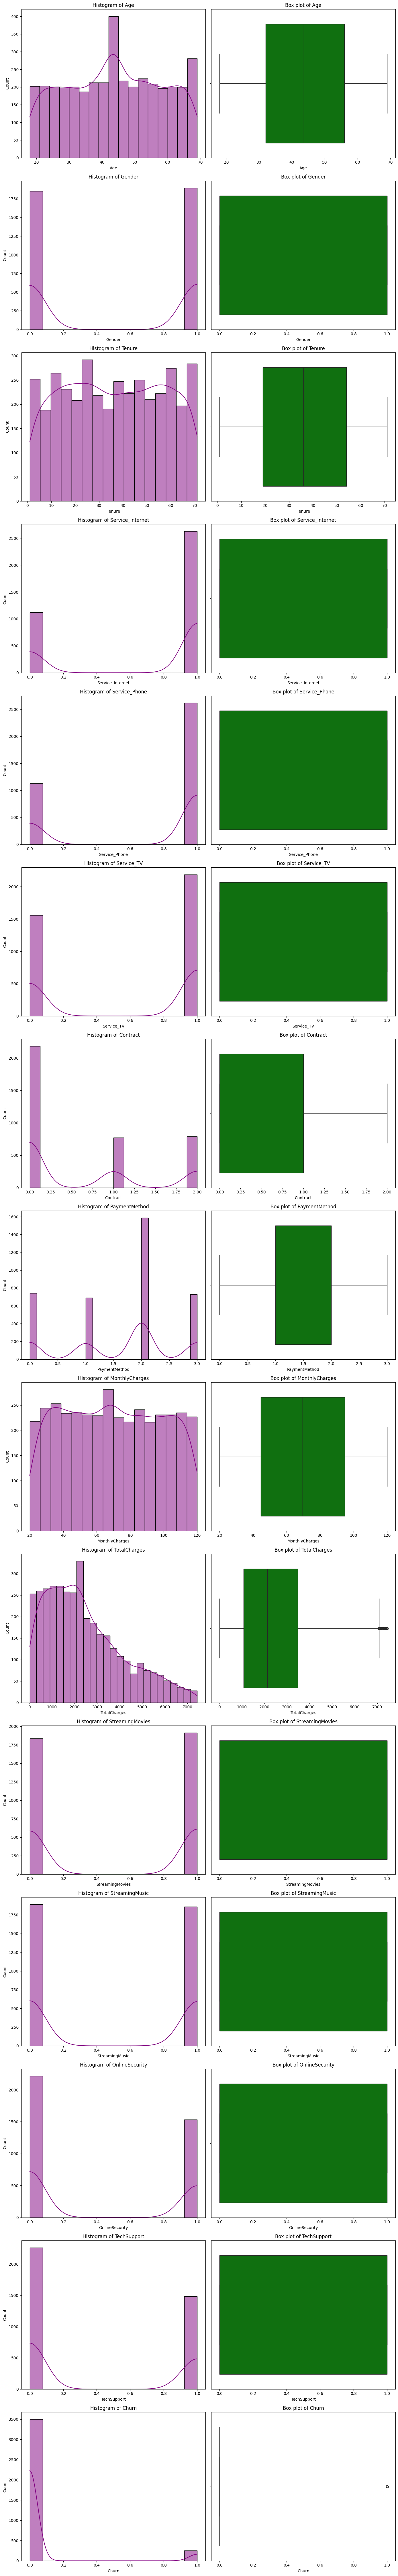

In [ ]:
numerical_features = df.select_dtypes(include=['number']).columns

fig, axes = plt.subplots(len(numerical_features), 2, figsize=(14, len(numerical_features) * 6))

# Iterate through the numerical features
for i, col in enumerate(numerical_features):
    # Create the histogram
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i, 0], color='purple')
    axes[i, 0].set_title(f'Histogram of {col}')

    # Create the box plot
    sns.boxplot(x=df[col].dropna(), ax=axes[i, 1], color='green')
    axes[i, 1].set_title(f'Box plot of {col}')

plt.tight_layout()
plt.show()

Hypothesis Testing

In [ ]:
churned_df = df[df['Churn'] == 1]
non_churned_df = df[df['Churn'] == 0]

# Iterating through numerical features and performed t-tests
for feature in numerical_cols:
    t_statistic, p_value = stats.ttest_ind(churned_df[feature], non_churned_df[feature])
    print(f"T-test for {feature}: T-statistic = {t_statistic:.2f}, P-value = {p_value:.3f}")

# Iterating through categorical features and performed chi-squared tests
for feature in categorical_cols:
    contingency_table = pd.crosstab(df['Churn'], df[feature])
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
    print(f"Chi-squared test for {feature}: Chi2 = {chi2:.2f}, P-value = {p:.3f}")

T-test for Age: T-statistic = -0.21, P-value = 0.835
T-test for Tenure: T-statistic = -26.16, P-value = 0.000
T-test for MonthlyCharges: T-statistic = 15.08, P-value = 0.000
T-test for TotalCharges: T-statistic = -17.95, P-value = 0.000
Chi-squared test for Gender: Chi2 = 0.12, P-value = 0.731
Chi-squared test for Service_Internet: Chi2 = 0.05, P-value = 0.829
Chi-squared test for Service_Phone: Chi2 = 1.29, P-value = 0.256
Chi-squared test for Service_TV: Chi2 = 0.07, P-value = 0.792
Chi-squared test for Contract: Chi2 = 1.43, P-value = 0.488
Chi-squared test for PaymentMethod: Chi2 = 0.55, P-value = 0.908
Chi-squared test for StreamingMovies: Chi2 = 0.04, P-value = 0.837
Chi-squared test for StreamingMusic: Chi2 = 0.27, P-value = 0.605
Chi-squared test for OnlineSecurity: Chi2 = 0.48, P-value = 0.489
Chi-squared test for TechSupport: Chi2 = 1.15, P-value = 0.285
Chi-squared test for Churn: Chi2 = 3733.01, P-value = 0.000


**Feature Engineering**

Creating New Features

In [ ]:
# To create interaction terms between a customer's monthly spending and their contract commitment
df['MonthlyCharges_Contract'] = df['MonthlyCharges'] * df['Contract']

In [ ]:
# To check how long a customer stays with the company relative to their age
df['TenuretoAgeRatio'] = df['Tenure'] / df['Age']

In [ ]:
# To know how consistent a customer's spending is over time
df['MonthlyTotallyChargesRatio'] = df['MonthlyCharges'] / df['TotalCharges']

In [ ]:
# To find the total number of services a customer subscribes to
df['TotalServiceUsage'] = df['Service_Internet'] + df['Service_Phone'] + df['Service_TV']

In [ ]:
# To check if the newly created features are added to the dataset
df.head()

,Age,Gender,Tenure,Service_Internet,Service_Phone,Service_TV,Contract,PaymentMethod,MonthlyCharges,TotalCharges,StreamingMovies,StreamingMusic,OnlineSecurity,TechSupport,Churn,MonthlyCharges_Contract,TenuretoAgeRatio,MonthlyTotallyChargesRatio,TotalServiceUsage
0,56.0,1,13.0,0,1,0,1,3,71.88,931.49,0,0,1,0,0,71.88,0.232143,0.077167,1
1,69.0,1,13.0,0,0,1,2,3,110.99,1448.46,1,1,0,0,0,221.98,0.188406,0.076626,1
2,46.0,1,60.0,1,0,1,0,3,116.74,6997.73,1,1,0,0,0,0.00,1.304348,0.016683,2
3,32.0,0,57.0,1,1,1,0,0,78.16,4452.13,0,1,0,1,0,0.00,1.781250,0.017556,3
4,60.0,1,52.0,1,1,1,2,2,30.33,1569.73,1,0,1,1,0,60.66,0.866667,0.019322,3


<ipython-input-33-4c3c62ff068a>:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[feature_index].set_xticklabels(axes[feature_index].get_xticklabels(), rotation=45, ha='right')
<ipython-input-33-4c3c62ff068a>:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[feature_index].set_xticklabels(axes[feature_index].get_xticklabels(), rotation=45, ha='right')
<ipython-input-33-4c3c62ff068a>:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[feature_index].set_xticklabels(axes[feature_index].get_xticklabels(), rotation=45, ha='right')
<ipython-input-33-4c3c62ff068a>:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[feature_index].set_xticklabels(

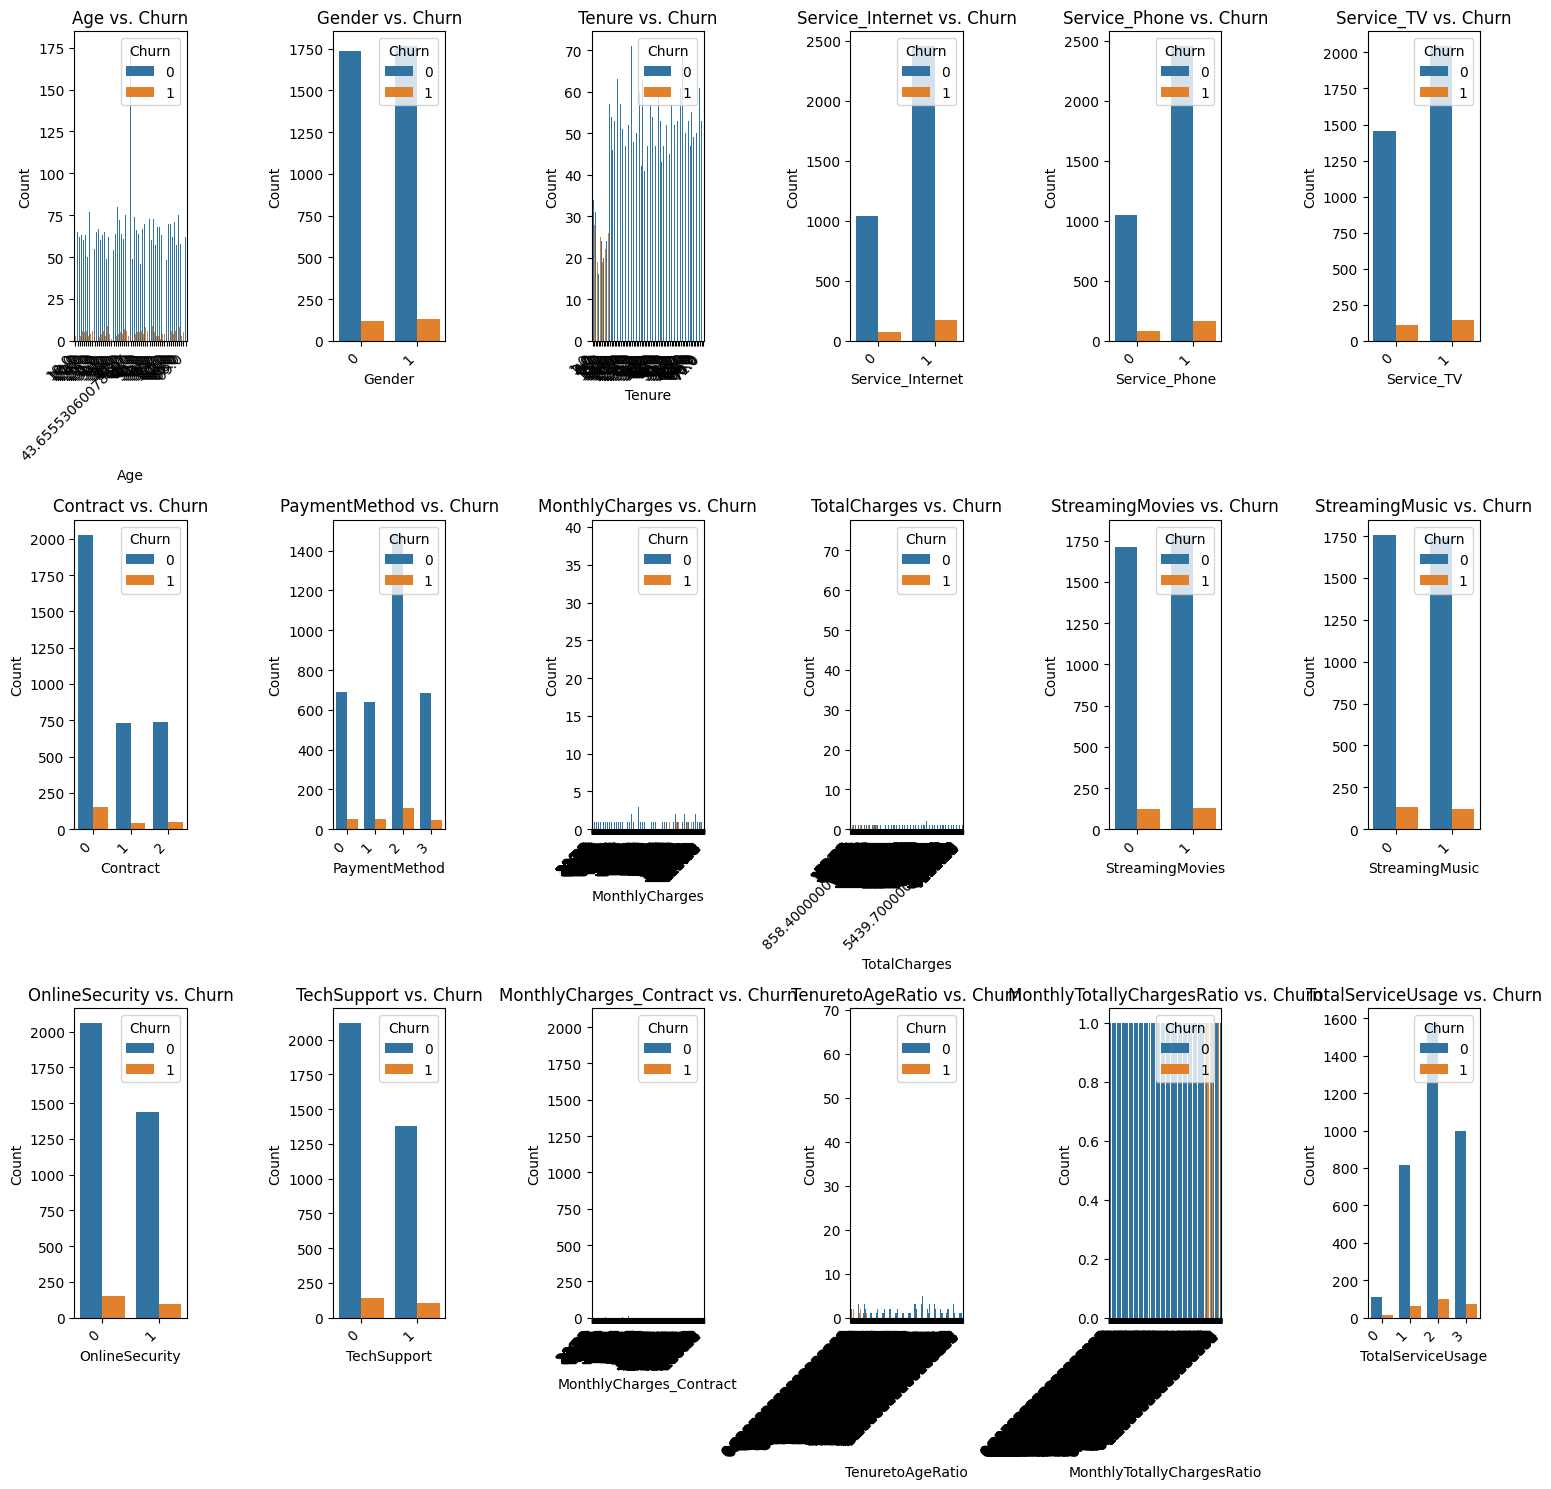

In [ ]:
num_features = len(df.columns) - 1
num_cols = 6
num_rows = (num_features + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 5))

axes = axes.flatten()

feature_index = 0
for feature in df.columns:
  if feature != 'Churn':
    sns.countplot(x=feature, hue='Churn', data=df, ax=axes[feature_index])
    axes[feature_index].set_title(f'{feature} vs. Churn')
    axes[feature_index].set_xlabel(feature)
    axes[feature_index].set_ylabel('Count')
    axes[feature_index].tick_params(axis='x', rotation=45)
    axes[feature_index].set_xticklabels(axes[feature_index].get_xticklabels(), rotation=45, ha='right')

    feature_index += 1

for i in range(feature_index, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
df.to_csv('dataset_with_new_features.csv', index=False)

Defining the features and the target variable

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

Clustering

Tested kMeans with k = 1	Inertia: 11500974739.1452
Tested kMeans with k = 2	Inertia: 3441471072.1266
Tested kMeans with k = 3	Inertia: 1594357156.2416
Tested kMeans with k = 4	Inertia: 900200964.1287
Tested kMeans with k = 5	Inertia: 606749031.4866
Tested kMeans with k = 6	Inertia: 445492245.5435
Tested kMeans with k = 7	Inertia: 312907791.3567
Tested kMeans with k = 8	Inertia: 257566406.2543
Tested kMeans with k = 9	Inertia: 198888845.7111
Tested kMeans with k = 10	Inertia: 159534346.9142
Tested kMeans with k = 11	Inertia: 136692583.6094
Tested kMeans with k = 12	Inertia: 120584132.7047
Tested kMeans with k = 13	Inertia: 105125084.3360
Tested kMeans with k = 14	Inertia: 92257405.7845
Tested kMeans with k = 15	Inertia: 84909711.3657
Tested kMeans with k = 16	Inertia: 75533496.0294
Tested kMeans with k = 17	Inertia: 68768236.0209
Tested kMeans with k = 18	Inertia: 63710753.1580


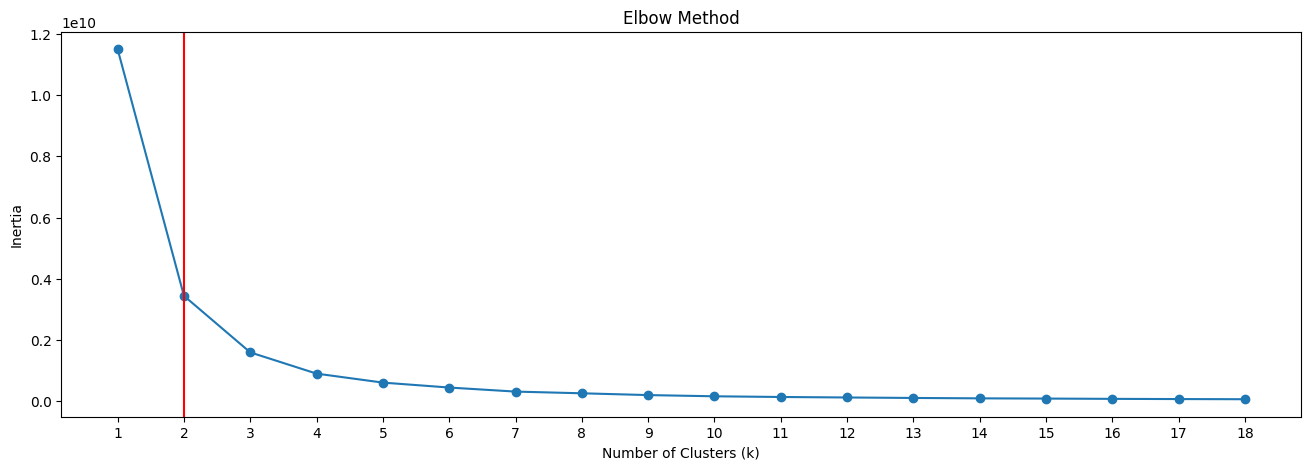

In [ ]:
inertia = []
for k in range(1,19,1):
    kmeans = KMeans(n_clusters = k,random_state = 1234)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    y_pred = kmeans.predict(X)
    print("Tested kMeans with k = %d\tInertia: %5.4f" % (k, kmeans.inertia_))

plt.figure(figsize = (16,5))
plt.plot(inertia, marker='o')
plt.xticks(range(0,18,1),range(1,19,1))
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.axvline(1, color = "r")
plt.show()

**Modeling**

Building and Evaluating Models

In [ ]:
def print_model_evaluation(model, X_train, y_train, X_test, y_test, model_name):
  # Train and predict
  model.fit(X_train, y_train)
  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)
  y_pred_proba = model.predict_proba(X_test)[:, 1]  # For ROC-AUC

  # Metrics
  train_accuracy = accuracy_score(y_train, y_train_pred) * 100
  test_accuracy = accuracy_score(y_test, y_test_pred) * 100
  roc_auc = roc_auc_score(y_test, y_pred_proba) *100

  # Classification report and confusion matrix
  train_class_report = classification_report(y_train, y_train_pred)
  test_class_report = classification_report(y_test, y_test_pred)
  train_conf_matrix = confusion_matrix(y_train, y_train_pred)
  test_conf_matrix = confusion_matrix(y_test, y_test_pred)

  # Print results
  print(f"Model: {model_name}")
  print(f"Train Accuracy: {train_accuracy:.2f}%")
  print(f"Test Accuracy: {test_accuracy:.2f}%")
  print(f"ROC-AUC: {roc_auc:.2f}")
  print("\nClassification Report (Train):")
  print(train_class_report)
  print("\nClassification Report (Test):")
  print(test_class_report)

  # Confusion Matrix Figure
  plt.figure(figsize=(4,2))
  sns.heatmap(pd.DataFrame(train_conf_matrix), annot=True, cmap="RdBu" ,fmt='g')
  plt.tight_layout()
  plt.title('Confusion matrix (Train)', y=1)
  plt.ylabel('Actual label')
  plt.xlabel('Predicted label')
  plt.show()

  plt.figure(figsize=(4,2))
  sns.heatmap(pd.DataFrame(test_conf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
  plt.tight_layout()
  plt.title('Confusion matrix (Test)', y=1)
  plt.ylabel('Actual label')
  plt.xlabel('Predicted label')
  plt.show()

  # ROC-AUC Figure
  RocCurveDisplay.from_estimator(model, X_test, y_test, name=model_name)
  plt.show()

  with open(f'{model_name}_model.pkl', 'wb') as file:
    pickle.dump(model, file)
  print(f"Model saved as {model_name}_model.pkl")

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

((2999, 18), (750, 18), (2999,), (750,))

In [ ]:
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model: Logistic Regression
Train Accuracy: 98.63%
Test Accuracy: 98.27%
ROC-AUC: 98.28

Classification Report (Train):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2809
           1       0.92      0.86      0.89       190

    accuracy                           0.99      2999
   macro avg       0.95      0.93      0.94      2999
weighted avg       0.99      0.99      0.99      2999


Classification Report (Test):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       689
           1       0.91      0.87      0.89        61

    accuracy                           0.98       750
   macro avg       0.95      0.93      0.94       750
weighted avg       0.98      0.98      0.98       750



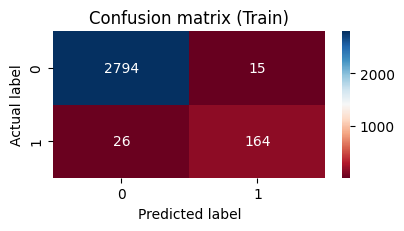

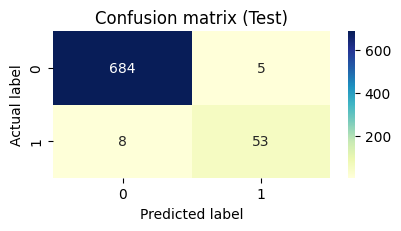

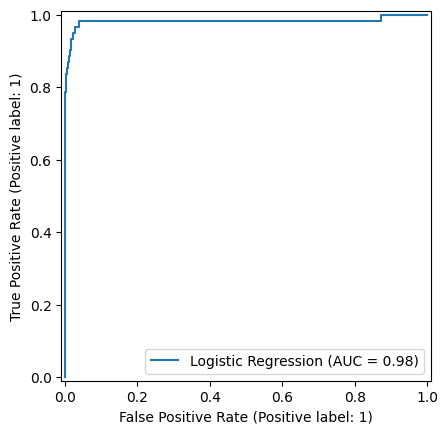

Model saved as Logistic Regression_model.pkl


In [ ]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000,random_state=42)
print_model_evaluation(lr_model, X_train, y_train, X_test, y_test,'Logistic Regression')

Model: Random Forest Classifier
Train Accuracy: 100.00%
Test Accuracy: 99.87%
ROC-AUC: 100.00

Classification Report (Train):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2809
           1       1.00      1.00      1.00       190

    accuracy                           1.00      2999
   macro avg       1.00      1.00      1.00      2999
weighted avg       1.00      1.00      1.00      2999


Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       689
           1       1.00      0.98      0.99        61

    accuracy                           1.00       750
   macro avg       1.00      0.99      1.00       750
weighted avg       1.00      1.00      1.00       750



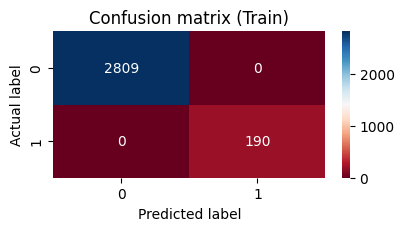

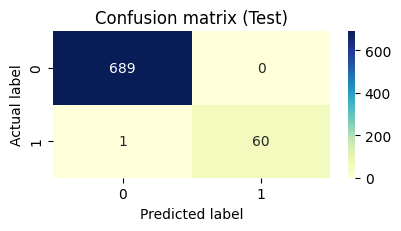

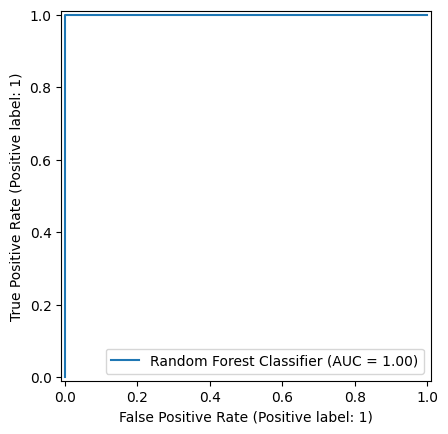

Model saved as Random Forest Classifier_model.pkl


In [ ]:
# Random Forest Classifier
rf_model = RandomForestClassifier()
print_model_evaluation(rf_model, X_train, y_train, X_test, y_test,'Random Forest Classifier')

Model: Decision Tree Classifier
Train Accuracy: 100.00%
Test Accuracy: 99.87%
ROC-AUC: 99.18

Classification Report (Train):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2809
           1       1.00      1.00      1.00       190

    accuracy                           1.00      2999
   macro avg       1.00      1.00      1.00      2999
weighted avg       1.00      1.00      1.00      2999


Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       689
           1       1.00      0.98      0.99        61

    accuracy                           1.00       750
   macro avg       1.00      0.99      1.00       750
weighted avg       1.00      1.00      1.00       750



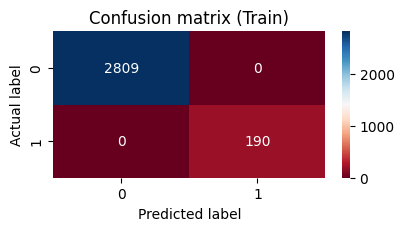

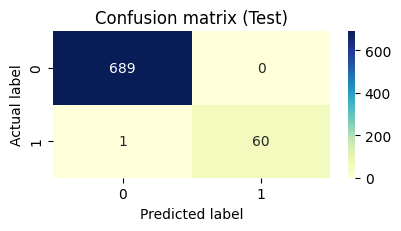

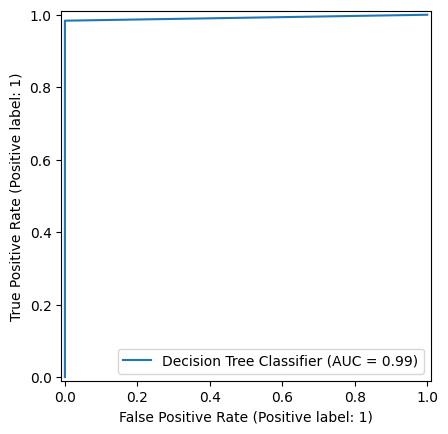

Model saved as Decision Tree Classifier_model.pkl


In [ ]:
# Decision Tree Classifier
dt_model = DecisionTreeClassifier()
print_model_evaluation(dt_model, X_train, y_train, X_test, y_test,'Decision Tree Classifier')

Model: Gradient Boosting
Train Accuracy: 100.00%
Test Accuracy: 99.87%
ROC-AUC: 99.11

Classification Report (Train):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2809
           1       1.00      1.00      1.00       190

    accuracy                           1.00      2999
   macro avg       1.00      1.00      1.00      2999
weighted avg       1.00      1.00      1.00      2999


Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       689
           1       1.00      0.98      0.99        61

    accuracy                           1.00       750
   macro avg       1.00      0.99      1.00       750
weighted avg       1.00      1.00      1.00       750



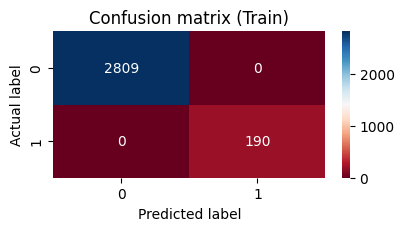

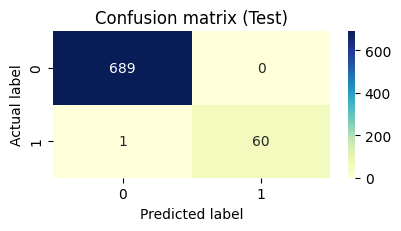

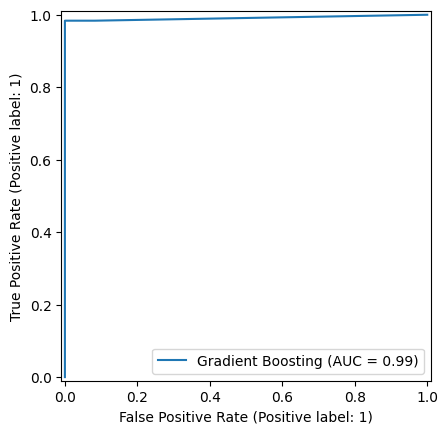

Model saved as Gradient Boosting_model.pkl


In [ ]:
# Gradient Boosting Classifier
gb_model = GradientBoostingClassifier()
print_model_evaluation(gb_model, X_train, y_train, X_test, y_test, 'Gradient Boosting')

Cross Validation

In [ ]:
def perform_cross_validation(model, X, y, cv=5):
    cv_scores = cross_val_score(model, X, y, cv=cv)
    return cv_scores.mean()

In [ ]:
# Cross-validation for each model
lr_cv_accuracy = perform_cross_validation(lr_model, X, y)
rf_cv_accuracy = perform_cross_validation(rf_model, X, y)
dt_cv_accuracy = perform_cross_validation(dt_model, X, y)
gb_cv_accuracy = perform_cross_validation(gb_model, X, y)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
cv_results = {
    "Logistic Regression": lr_cv_accuracy,
    "Random Forest Classifier": rf_cv_accuracy,
    "Decision Tree Classifier": dt_cv_accuracy,
    "Gradient Boosting": gb_cv_accuracy
}

# Convert to percentage format and print
formatted_results = {model: f"{accuracy * 100:.2f}%" for model, accuracy in cv_results.items()}
formatted_results

{'Logistic Regression': '98.24%',
 'Random Forest Classifier': '99.95%',
 'Decision Tree Classifier': '99.84%',
 'Gradient Boosting': '99.87%'}

**Model Tuning**

Hyperparameter Tuning

In [ ]:
param_dist_lr = {
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'C': uniform(0.01, 10),  # Inverse of regularization strength
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
    'max_iter': [100, 200, 500]
}

random_search_lr = RandomizedSearchCV(lr_model, param_distributions=param_dist_lr, n_iter=50, cv=5, scoring='accuracy')

random_search_lr.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

RandomizedSearchCV(cv=5,
                   estimator=LogisticRegression(max_iter=1000, random_state=42),
                   n_iter=50,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7a17f5f3f880>,
                                        'max_iter': [100, 200, 500],
                                        'penalty': ['l1', 'l2', 'elasticnet',
                                                    'none'],
                                        'solver': ['newton-cg', 'lbfgs',
                                                   'liblinear', 'sag',
                                                   'saga']},
                   scoring='accuracy')

In [ ]:
random_search_lr.best_params_

{'C': 10.00166434639249,
 'max_iter': 500,
 'penalty': 'l2',
 'solver': 'newton-cg'}

In [ ]:
best_lr_model = random_search_lr.best_estimator_

# Evaluate the model on the test set
y_pred = best_lr_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.984


              precision    recall  f1-score   support

           0       0.99      1.00      0.99       689
           1       0.95      0.85      0.90        61

    accuracy                           0.98       750
   macro avg       0.97      0.92      0.94       750
weighted avg       0.98      0.98      0.98       750



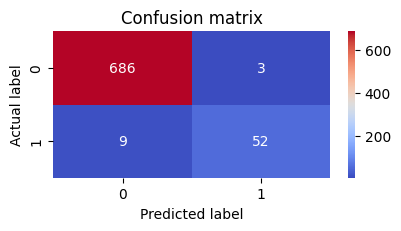

Model saved as Logistic_Regression_tuned_model.pkl


In [ ]:
# Evaluation
conf_matrix = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))

plt.figure(figsize=(4,2))
sns.heatmap(pd.DataFrame(conf_matrix), annot=True, cmap="coolwarm" ,fmt='g')
plt.tight_layout()
plt.title('Confusion matrix', y=1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

with open('Logistic_Regression_tuned_model.pkl', 'wb') as file:
    pickle.dump(best_lr_model, file)
print("Model saved as Logistic_Regression_tuned_model.pkl")

In [ ]:
param_dist_rf = {
    'n_estimators': range(50, 200),
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': uniform(0.01, 0.199)
}
rf_model = RandomForestClassifier()

random_search_rf = RandomizedSearchCV(rf_model, param_distributions=param_dist_rf, n_iter=50, cv=5, scoring='accuracy')

random_search_rf.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=50,
                   param_distributions={'max_depth': [None, 5, 10, 15],
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7a17f5d5ea70>,
                                        'n_estimators': range(50, 200)},
                   scoring='accuracy')

In [ ]:
random_search_rf.best_params_

{'max_depth': 5, 'min_samples_split': 0.03009126774479965, 'n_estimators': 195}

In [ ]:
# Get the best model
best_rf_model = random_search_rf.best_estimator_

# Evaluate the model on the test set
y_pred = best_rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.9986666666666667


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       689
           1       1.00      0.98      0.99        61

    accuracy                           1.00       750
   macro avg       1.00      0.99      1.00       750
weighted avg       1.00      1.00      1.00       750



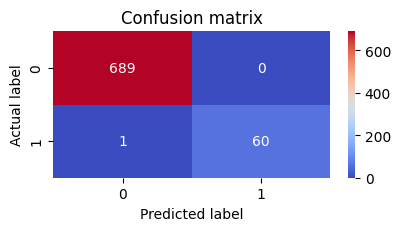

Model saved as Random_Forest_tuned_model.pkl


In [ ]:
# Evaluation
conf_matrix = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))

plt.figure(figsize=(4,2))
sns.heatmap(pd.DataFrame(conf_matrix), annot=True, cmap="coolwarm" ,fmt='g')
plt.tight_layout()
plt.title('Confusion matrix', y=1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

with open('Random_Forest_tuned_model.pkl', 'wb') as file:
    pickle.dump(best_rf_model, file)
print("Model saved as Random_Forest_tuned_model.pkl")

In [ ]:
param_dist_dt = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': range(2, 11),
    'min_samples_leaf': range(1, 5),
    'max_features': ['auto', 'sqrt', 'log2']
}

random_search_dt = RandomizedSearchCV(dt_model, param_distributions=param_dist_dt, n_iter=50, cv=5, scoring='accuracy')

random_search_dt.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
105 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
105 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/util

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_iter=50,
                   param_distributions={'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [None, 5, 10, 15, 20],
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': range(1, 5),
                                        'min_samples_split': range(2, 11)},
                   scoring='accuracy')

In [ ]:
random_search_dt.best_params_

{'min_samples_split': 8,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': None,
 'criterion': 'log_loss'}

In [ ]:
best_dt_model = random_search_dt.best_estimator_

# Evaluate the model on the test set
y_pred = best_dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.9933333333333333


              precision    recall  f1-score   support

           0       0.99      1.00      1.00       689
           1       1.00      0.92      0.96        61

    accuracy                           0.99       750
   macro avg       1.00      0.96      0.98       750
weighted avg       0.99      0.99      0.99       750



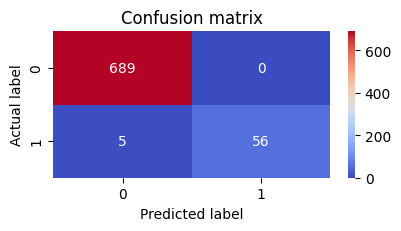

Model saved as Decision_Tree_tuned_model.pkl


In [ ]:
# Evaluation
conf_matrix = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))

plt.figure(figsize=(4,2))
sns.heatmap(pd.DataFrame(conf_matrix), annot=True, cmap="coolwarm" ,fmt='g')
plt.tight_layout()
plt.title('Confusion matrix', y=1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

with open('Decision_Tree_tuned_model.pkl', 'wb') as file:
    pickle.dump(best_dt_model, file)
print("Model saved as Decision_Tree_tuned_model.pkl")

In [ ]:
param_dist_gb = {
    'n_estimators': range(50, 200),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': [3, 5, 7, 9],
    'min_samples_split': range(2, 11),
    'min_samples_leaf': range(1, 5),
    'subsample': uniform(0.6, 0.4),
    'max_features': ['auto', 'sqrt', 'log2']
}

random_search_gb = RandomizedSearchCV(gb_model, param_distributions=param_dist_gb, n_iter=50, cv=5, scoring='accuracy')

random_search_gb.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
65 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
65 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_iter=50,
                   param_distributions={'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7a17f5e47250>,
                                        'max_depth': [3, 5, 7, 9],
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': range(1, 5),
                                        'min_samples_split': range(2, 11),
                                        'n_estimators': range(50, 200),
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7a17f5d1f010>},
                   scoring='accuracy')

In [ ]:
random_search_gb.best_params_

{'learning_rate': 0.19400838254192282,
 'max_depth': 7,
 'max_features': 'log2',
 'min_samples_leaf': 3,
 'min_samples_split': 8,
 'n_estimators': 114,
 'subsample': 0.7367492903618695}

In [ ]:
best_gb_model = random_search_gb.best_estimator_

# Evaluate the model on the test set
y_pred = best_gb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 1.0


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       689
           1       1.00      1.00      1.00        61

    accuracy                           1.00       750
   macro avg       1.00      1.00      1.00       750
weighted avg       1.00      1.00      1.00       750



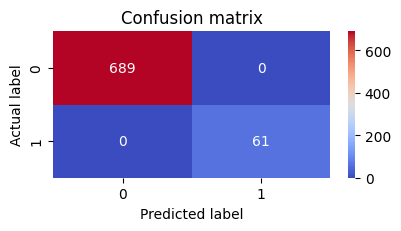

Model saved as Gradient_Boosting_tuned_model.pkl


In [ ]:
# Evaluation
conf_matrix = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))

plt.figure(figsize=(4,2))
sns.heatmap(pd.DataFrame(conf_matrix), annot=True, cmap="coolwarm" ,fmt='g')
plt.tight_layout()
plt.title('Confusion matrix', y=1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

with open('Gradient_Boosting_tuned_model.pkl', 'wb') as file:
    pickle.dump(best_gb_model, file)
print("Model saved as Gradient_Boosting_tuned_model.pkl")

**Model Interpretation**

Feature ranking:
1. MonthlyCharges (0.570216)
2. MonthlyTotallyChargesRatio (0.421249)
3. Tenure (0.005688)
4. PaymentMethod (0.002847)
5. Gender (0.000000)
6. Service_Internet (0.000000)
7. Service_Phone (0.000000)
8. Service_TV (0.000000)
9. Contract (0.000000)
10. TotalServiceUsage (0.000000)
11. TotalCharges (0.000000)
12. StreamingMovies (0.000000)
13. StreamingMusic (0.000000)
14. OnlineSecurity (0.000000)
15. TechSupport (0.000000)
16. MonthlyCharges_Contract (0.000000)
17. TenuretoAgeRatio (0.000000)
18. Age (0.000000)


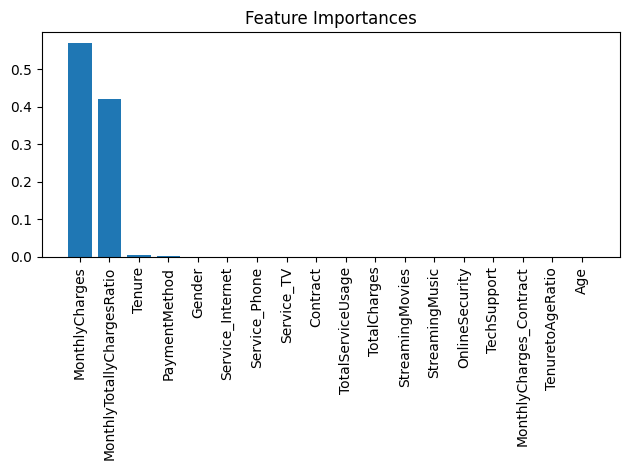

In [ ]:
dt_model.fit(X, y)
importances = dt_model.feature_importances_
feature_names = X.columns

indices = np.argsort(importances)[::-1]

print("Feature ranking:")
for f in range(X.shape[1]):
    print("%d. %s (%f)" % (f + 1, feature_names[indices[f]], importances[indices[f]]))

plt.figure()
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

Feature ranking:
1. MonthlyCharges (0.327561)
2. Tenure (0.211476)
3. MonthlyTotallyChargesRatio (0.166640)
4. TotalCharges (0.126718)
5. TenuretoAgeRatio (0.107814)
6. MonthlyCharges_Contract (0.026793)
7. Age (0.010182)
8. Contract (0.006262)
9. TotalServiceUsage (0.003306)
10. PaymentMethod (0.003056)
11. StreamingMusic (0.002284)
12. OnlineSecurity (0.001696)
13. StreamingMovies (0.001524)
14. TechSupport (0.001149)
15. Service_TV (0.001106)
16. Gender (0.000836)
17. Service_Internet (0.000817)
18. Service_Phone (0.000780)


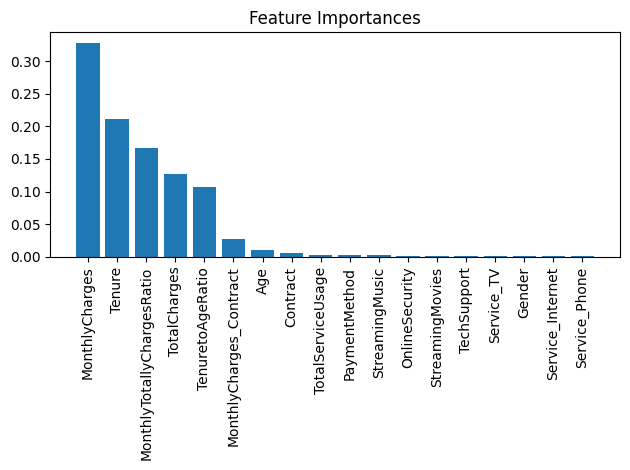

In [ ]:
rf_model.fit(X, y)
importances = rf_model.feature_importances_
feature_names = X.columns

indices = np.argsort(importances)[::-1]

print("Feature ranking:")
for f in range(X.shape[1]):
    print("%d. %s (%f)" % (f + 1, feature_names[indices[f]], importances[indices[f]]))

plt.figure()
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Get indices of important features for each model
dt_indices = indices[importances[indices] > 0.2]
rf_indices = indices[importances[indices] > 0.1]

# Extract feature names using the indices
dt_features = feature_names[dt_indices]
rf_features = feature_names[rf_indices]

In [ ]:
selected_features = set(dt_features).union(rf_features)

X_features = X[list(selected_features)]
X_features

,TotalCharges,MonthlyCharges,TenuretoAgeRatio,Tenure,MonthlyTotallyChargesRatio
0,931.49,71.88,0.232143,13.0,0.077167
1,1448.46,110.99,0.188406,13.0,0.076626
2,6997.73,116.74,1.304348,60.0,0.016683
3,4452.13,78.16,1.781250,57.0,0.017556
4,1569.73,30.33,0.866667,52.0,0.019322
...,...,...,...,...,...
3744,3608.50,61.14,0.967213,59.0,0.016943
3745,1784.38,34.15,1.444444,52.0,0.019138
3746,594.41,30.79,0.655172,19.0,0.051799
3747,1715.08,80.56,0.840000,21.0,0.046972
